<a href="https://colab.research.google.com/github/murucomus/BAN6420-Assignments/blob/main/Teleconnect_Churn_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP 1: Importing Libraries

Import the required libraries - for a start, those that help with data importation and exploration - numpy, pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv('Teleconnect.csv')

# STEP 2: Understand the Data

Check the records in the data

In [ ]:
dataset.shape #it has 7043 records with 21 columns

(7043, 21)

Show the columns in the dataset

In [ ]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Show statistical description of the data

In [ ]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Display 10 records of the data

In [ ]:
dataset.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Lets check the number of customers who have "churned" so far - their status is indicated in the Churn column of the dataset

In [ ]:
dataset["Churn"].value_counts() #so there are 1869 customers

No     5174
Yes    1869
Name: Churn, dtype: int64

# STEP 3: Data cleaning

At this stage, clean and prepare the data ready for visualization - remove duplicates and nulls in the data

In [ ]:
dataset.isna().sum() #check the nulls per column

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

As we can see, the dataset is okay and the values are all in

# STEP 4: Data Exploration(Visualization)

Lets add some styling

In [ ]:
plt.style.use('ggplot')

Lets explore the customer to understand the demographics better

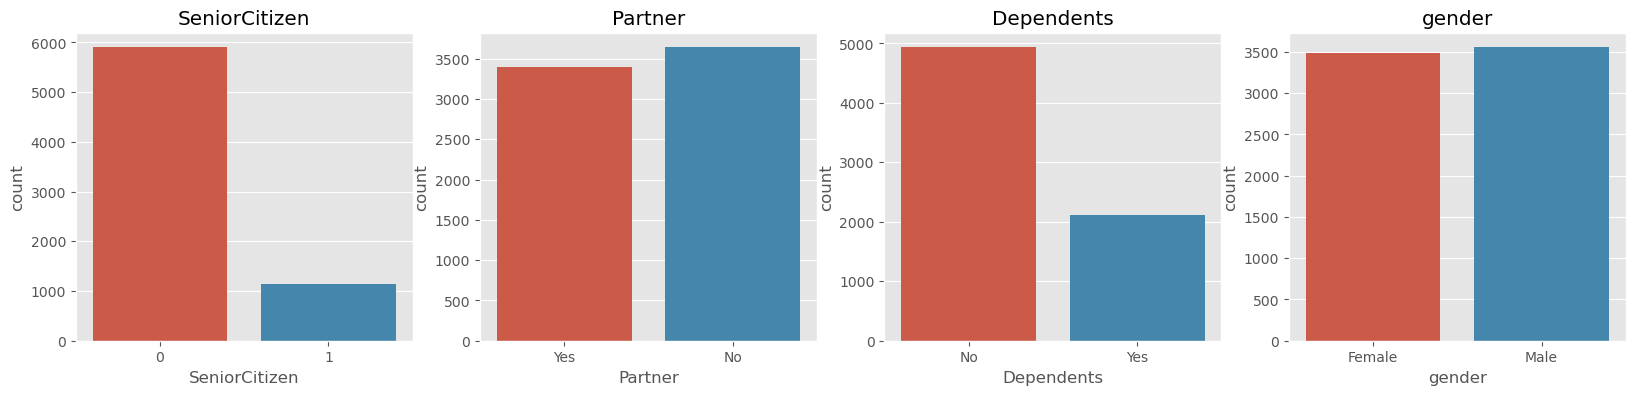

In [ ]:
dataset_columns = ['SeniorCitizen',"Partner","Dependents","gender"]
nums = dataset_columns

plt.figure(figsize=(20,4))

for i, column in enumerate(nums):
    axs = plt.subplot(1, len(nums), i+1)
    sns.countplot(x=str(column), data=dataset)
    axs.set_title(f"{column}")

From the charts we can see the following groups of customers:
1. More younger customers
2. More customers without partners
3. More customers without dependants
4. Slightly higher male customers

Lets explore the relationship between:
    1. The churn and the monthly charges incurred by the customers - it is expected that those that churn more tend to have a higher bill/charge
    2. The churn and the other subscription service - will help understand if they found other services more important or could not afford all the services and decided to drop this service

 1. The churn and the monthly charges incurred by the customers

<AxesSubplot:xlabel='Churn', ylabel='MonthlyCharges'>

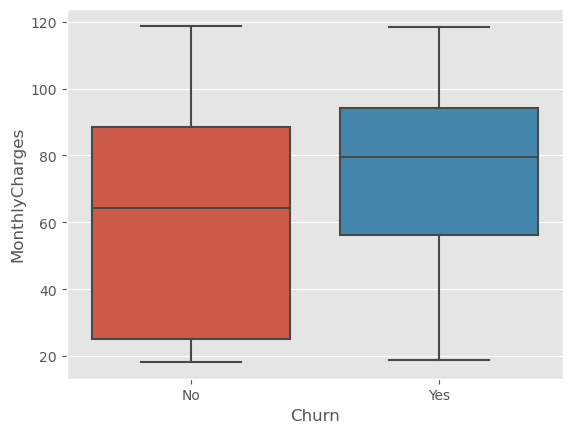

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=dataset)

As expected, the ones who pay more monthly charges tend to churn more

2. The churn and the other subscription service

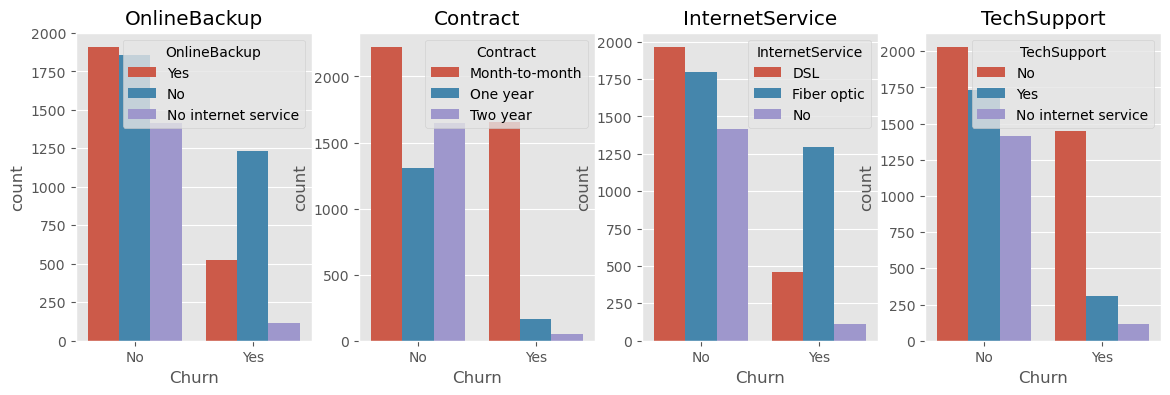

In [ ]:
columns = ["OnlineBackup","Contract","InternetService","TechSupport",]

plt.figure(figsize=(14,4))

for j, col in enumerate(columns):
    axs = plt.subplot(1, len(columns), j+1)
    sns.countplot(x ="Churn", hue = str(col), data = dataset)
    axs.set_title(f"{col}")

It can be seen that those without tech support and on month-to-month contracts churned more. This is expected - if a customer does not have good customer support, they have no place to channel their issues and could end up dropping. Similarly a customer who is not tied on a yearly contract could fail to renew their contract much easier that one on yearly one since they have to wait until the end of the year.

Lets go back to the data and do some more cleaning and transformatio of the data. For example, all the columns whose values can be represented categorically can be encoded. So what are the categorical features in the data?

... these could include; columns with yes/no, genders. We drop the other columns from the dataframe for now to allow to do the data transformation of the feature variables data

In [ ]:
categorical_features = dataset.drop(['customerID','TotalCharges','MonthlyCharges','SeniorCitizen','tenure'],axis=1)

categorical_features.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


Categorical_features becomes the new dataset

Lets now include sklearn to help us transform(encode) the values into 1,2,3,...

In [ ]:
from sklearn import preprocessing
#define the label encoder
label_encoder = preprocessing.LabelEncoder()
dataset_category = categorical_features.apply(label_encoder.fit_transform)


Display the encoded data

In [ ]:
dataset_category.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,0
1,1,0,0,1,0,0,2,0,2,0,0,0,1,0,3,0
2,1,0,0,1,0,0,2,2,0,0,0,0,0,1,3,1
3,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1


We now need to merge the previously dropped columns to the new created dataframe

In [ ]:
previously_dropped_features = dataset[['customerID','TotalCharges','MonthlyCharges','SeniorCitizen','tenure']]
final_dataset = pd.merge(previously_dropped_features, dataset_category, left_index=True, right_index=True)

In [ ]:
final_dataset.head()

,customerID,TotalCharges,MonthlyCharges,SeniorCitizen,tenure,gender,Partner,Dependents,PhoneService,MultipleLines,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,29.85,29.85,0,1,0,1,0,0,1,...,0,2,0,0,0,0,0,1,2,0
1,5575-GNVDE,1889.5,56.95,0,34,1,0,0,1,0,...,2,0,2,0,0,0,1,0,3,0
2,3668-QPYBK,108.15,53.85,0,2,1,0,0,1,0,...,2,2,0,0,0,0,0,1,3,1
3,7795-CFOCW,1840.75,42.30,0,45,1,0,0,0,1,...,2,0,2,2,0,0,1,0,0,0
4,9237-HQITU,151.65,70.70,0,2,0,0,0,1,0,...,0,0,0,0,0,0,0,1,2,1


# STEP 5: Data preparation - splitting the dataset(training-testing)

During the model development, it is important to split the data into two/three(training, testing,validation). In most cases, only training and testing is done with a common ratio of 7:3

In [ ]:
final_dataset=final_dataset.drop(final_dataset.index[(final_dataset["TotalCharges"] == " ")],axis=0)

final_dataset['TotalCharges']=final_dataset.TotalCharges.astype(float)
final_dataset['TotalCharges'].dtype

dtype('float64')

From the above, we are converting the strings into float values for the TotalCharges column

In [ ]:
from sklearn.model_selection import train_test_split

final_dataset = final_dataset.dropna()
final_dataset = final_dataset.drop(['customerID'],axis=1) # we drop the customerid column - does not add anlytical value

X = final_dataset.drop(['Churn'],axis=1)
Y = final_dataset['Churn']
x_train,x_test,y_train,y_test=train_test_split(X,Y,train_size=0.75,stratify=Y)

Lets see the counts of the training and the testing datasets

In [ ]:
y_train.value_counts() # with 1402 who have churned

0    3872
1    1402
Name: Churn, dtype: int64

In [ ]:
y_test.value_counts() # with 467 who have churned

0    1291
1     467
Name: Churn, dtype: int64

If you look at this data, the total churned customers is roughly 27% - which means already 27% of a class total whose prediction would be on interest(churned) is not in the data while 73% of the data does not include any churning. This is a problem = we have a class imbalance and our prediction is already biased even before we develop the predictio model.

So, how do we address this. One of the ways is to use oversampling. What other ways can we use?... For today, lets use SMOTE from sklearn

In [ ]:
#install the imbalanced-learn
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote=SMOTE()
X_smote, y_smote=smote.fit_resample(x_train,y_train)
x_train, y_train = X_smote, y_smote

Now, lets check if the values are equal

In [ ]:
y_train.value_counts()

1    3872
0    3872
Name: Churn, dtype: int64

The dataset is balanced and ready for model building

# STEP 6: Building the prediction Model

Building the classifier can be implemented in several ways including: random forest classifier,

1. Using Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=46)
random_forest.fit(x_train,y_train)

RandomForestClassifier(random_state=46)

Hooray! Our model has trained the data(75%), now lets test the remaining 25%

In [ ]:
from sklearn.metrics import accuracy_score

prediction = random_forest.predict(x_test)
print(accuracy_score(prediction,y_test))

0.7690557451649602


As you can see, our model is not badly off at 77%

2. Using Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [ ]:
# Creating a function to create prediction model using the statsmodel library
# print details like model Summary, Confusion Matrix and Accuracy Score based on predicted values using test set

def get_sm_model(y_train,x_train, x_test):
    x_train = sm.add_constant(x_train)
    x_test = sm.add_constant(x_test)
    logit_model=sm.Logit(y_train,x_train)
    model=logit_model.fit()
    print(model.summary())
    y_hat = list(map(round, model.predict(x_test)))
    arr = np.c_[y_hat, y_test]
    print('\nPrinting predicted and actual values:\n',arr)
    print('Confusion Matrix \n',confusion_matrix(y_test, y_hat))
    print('Accuracy Score: ',accuracy_score(y_test, y_hat))
    return model, arr


In [ ]:
# Creating a function to create prediction model based on sklearn library and
# print details like model Summary, Confusion Matrix and Accuracy Score based on predicted values using test set

def get_sk_model(y_train,x_train, x_test):
    model = LogisticRegression(max_iter=100000000)
    model.fit(x_train, y_train)
    arr = np.c_[x_train.columns.tolist(),model.coef_[0]]
    intercept = model.intercept_[0]
    print('\nPrinting model coefficients and intercept summary for sklearn model:\n',arr, model.intercept_)
    y_pred = model.predict(x_test)
    print('\nPrinting predicted and actual values from sklearn:\n',np.c_[y_pred, y_test])
    print('Confusion Matrix from sklearn\n',confusion_matrix(y_test, y_pred))
    plt.matshow(confusion_matrix(y_test, y_pred))
    plt.title('Confusion matrix')
    plt.colorbar()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.grid(b=None)
    plt.show()
    print('Accuracy Scores from sklearn:\n',accuracy_score(y_test, y_pred))
    print('Classification Report from sklearn:\n',classification_report(y_test, y_pred))
    return model, arr, intercept


In [ ]:
# Function to create AUC chart and print AUC score.
# AUC score closer to 1 is considered a good model
# Auc score of 0.5 represents are model which is no
# better than a random guess with 50% chance of predicting the right outcome

from sklearn.metrics import roc_curve
def roc(model, x_test, y_test):
    probs = model.predict_proba(x_test)
    fpr, tpr, _ = roc_curve(y_test, probs[:,1])
    plt.plot(fpr, tpr, marker='.')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()
    print('AUC: %.3f' % roc_auc_score(y_test, probs[:,1]))

Optimization terminated successfully.
         Current function value: 0.420586
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7744
Model:                          Logit   Df Residuals:                     7724
Method:                           MLE   Df Model:                           19
Date:                Tue, 30 May 2023   Pseudo R-squ.:                  0.3932
Time:                        12:37:50   Log-Likelihood:                -3257.0
converged:                       True   LL-Null:                       -5367.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.1318      0.180     11.838      0.000       1.779       2.485
TotalCharge

C:\Users\user\AppData\Local\Temp\ipykernel_18876\392095147.py:18: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  plt.grid(b=None)


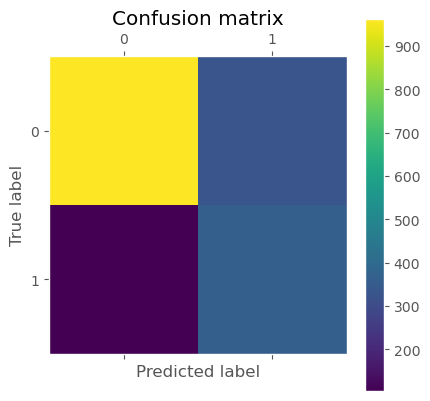

Accuracy Scores from sklearn:
 0.7536973833902162
Classification Report from sklearn:
               precision    recall  f1-score   support

           0       0.90      0.75      0.82      1291
           1       0.52      0.78      0.63       467

    accuracy                           0.75      1758
   macro avg       0.71      0.76      0.72      1758
weighted avg       0.80      0.75      0.77      1758



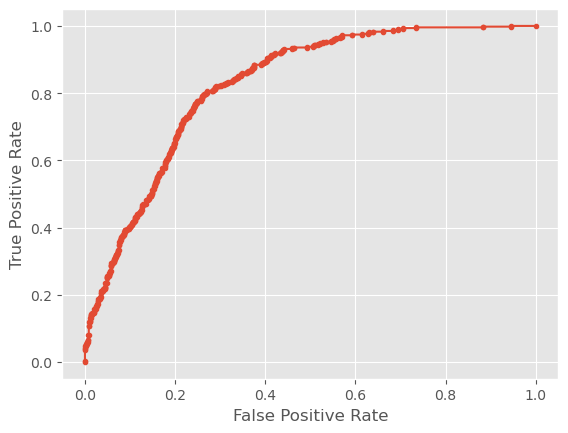

AUC: 0.824


In [ ]:
# Run statsmodel function
get_sm_model(y_train,x_train, x_test);
# Run sklearn model
model, arr, intercept = get_sk_model(y_train,x_train, x_test);
# Run AUC
roc(model, x_test, y_test);

We can also use the logistic regression function in the sklearn

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
linear_regression = LogisticRegression()
# fitting data in our model
linear_regression.fit(x_train,y_train)
# predicating x_test values which we saperated during train_test_split()
prediction = linear_regression.predict(x_test)

print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1291
           1       0.53      0.78      0.63       467

    accuracy                           0.75      1758
   macro avg       0.71      0.76      0.72      1758
weighted avg       0.80      0.75      0.77      1758



C:\Users\user\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


It gives an average accuracy of between 75%-77%